In [3]:
# Import the necessary modules
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch 
from torch import nn, optim
from torchdiffeq import odeint
import seaborn as sns

# Experiment 2
We will try to improve the results by employing a dropout NN. Two ways:
1. Retrain NN by applying the dropout from there
2. Retrain NN from scratch


## 2.1. 

In [133]:
def NP_firing_rate_fun(x):
    return 1 / (1 + np.exp(-x))

def many_monkeys(t, data, weights, phi, I):
    # Assume I is a vector of constants

    return np.array([
        - data[i] + phi( I[i] + np.sum([ weights[i,j] * data[j] for j in range(data.shape[0]) ])
        ) for i in range(data.shape[0])
    ]) 

In [134]:

saved_W = np.loadtxt("./cool_parameters/W_case2.np")
saved_I = np.loadtxt("./cool_parameters/I_case2.np")
saved_x0 = np.loadtxt("./cool_parameters/x0_case2.np")

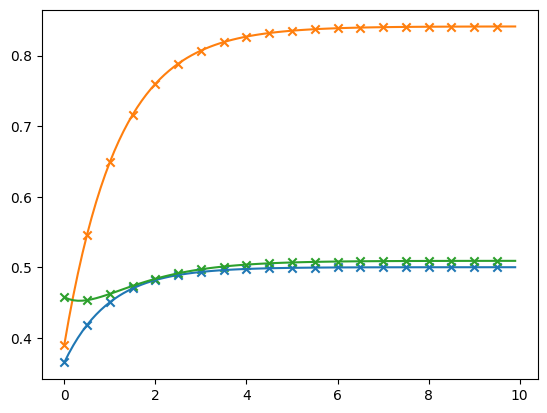

In [135]:
NEURON_NUM = 3
T_MAX = 10

sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = saved_x0, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(saved_W, NP_firing_rate_fun, saved_I),
                atol = 1e-8, rtol=1e-8)

                
data_train = sol.y[:, ::5]
t_train = sol.t[::5]



for i in range(NEURON_NUM):
    plt.plot(sol.t, sol.y[i])
    plt.scatter(t_train, data_train[i, :], marker="x")

plt.show()

In [136]:
def TORCH_firing_rate_fun(x):
    return 1 / (1 + torch.exp(-x))

class many_monkeys_mixed(nn.Module):
    def __init__(self, I0):
        super().__init__()


        self.register_buffer("I0", torch.tensor(I0, dtype=torch.float32))
        self.register_parameter("W", nn.Parameter(torch.zeros((NEURON_NUM, NEURON_NUM))))

        self.net = nn.Sequential(
            nn.Linear(1, 64),   #0
            nn.LeakyReLU(),     #1
            nn.Linear(64, 64),  #2
            nn.LeakyReLU(),     #3
            nn.Linear(64, 64),  #4
            nn.LeakyReLU(),     #5
            nn.Linear(64, 1),   #6
            nn.Softplus()       #7
        )

        # self.register_parameter("W", nn.Parameter(torch.tensor(saved_W, dtype=torch.float32))) # cheating mode

    def forward(self, t, data):
        x = self.I0 + self.W @ data.squeeze()
        x = x.unsqueeze(-1)
        out = self.net(x).squeeze(-1)
        return - data + out



In [137]:
# Train (fake) UDE network to training data
from tqdm import tqdm 
mixed_monkeys = many_monkeys_mixed(saved_I)
mixed_monkeys.load_state_dict(torch.load("./tmp/checkpoint3.x"))
mixed_monkeys.net = nn.Sequential(
            mixed_monkeys.net[0],
            mixed_monkeys.net[1],
            nn.Dropout(0.3),
            mixed_monkeys.net[2],
            mixed_monkeys.net[3],
            nn.Dropout(0.3),
            mixed_monkeys.net[4],
            mixed_monkeys.net[5],
            nn.Dropout(0.3),
            mixed_monkeys.net[6],
            mixed_monkeys.net[7],
        ) # recreate the NN with new dropout layers

optimizer = optim.Adamax(mixed_monkeys.parameters(), lr=0.005)
optimizer.load_state_dict(torch.load("./tmp/checkpoint3_optimizer.x"))

x0_torch = torch.tensor(saved_x0, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
data_train_torch = torch.tensor(data_train, dtype=torch.float32).T
W_tensor = torch.tensor(saved_W, dtype=torch.float32)

losses = []
frobenius_distances = []

print("Epoch\tLoss (L2 norm)\t2-norm difference in weight matrixes")
for EPOCH in (range(1, 5000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(mixed_monkeys, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - data_train_torch), 2)**2 
    loss_norm = loss_norm / T_train_torch.shape[0]

    loss_norm = loss_norm
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{loss_norm:.6E}\t{torch.norm(mixed_monkeys.W-W_tensor, 2):4f}")

        losses.append(loss_norm.detach().numpy())
        frobenius_distances.append(torch.norm(mixed_monkeys.W-W_tensor, 2).detach().numpy())


Epoch	Loss (L2 norm)	2-norm difference in weight matrixes
1	2.340459E-03	1.544205
2	2.992261E-03	1.541909
3	2.742290E-03	1.544992
4	1.900343E-03	1.547933
5	2.623008E-03	1.549456
6	2.247625E-03	1.548452
7	2.093695E-03	1.546535
8	2.087468E-03	1.543472
9	1.998834E-03	1.543365
10	3.110007E-03	1.545180
11	4.374269E-03	1.548160
12	2.285898E-03	1.551026
13	8.178605E-04	1.552770
14	1.962344E-03	1.553463
15	4.650152E-03	1.553934
16	4.069315E-03	1.553957
17	1.387397E-03	1.553333
18	2.472759E-03	1.551332
19	1.110242E-03	1.548224
20	9.524260E-04	1.545809
21	2.469985E-03	1.544729
22	1.389616E-03	1.543985
23	1.666719E-03	1.544324
24	9.317108E-04	1.544705
25	9.968879E-04	1.544574
26	1.723725E-03	1.543215
27	1.152125E-03	1.542561
28	1.491875E-03	1.541872
29	1.402552E-03	1.542235
30	1.712546E-03	1.541529
31	1.543758E-03	1.540000
32	7.504382E-04	1.538816
33	1.070218E-03	1.537837
34	1.108428E-03	1.537881
35	1.231723E-03	1.539003
36	8.135791E-04	1.539064
37	1.170812E-03	1.537453
38	1.154488E-03	1.534975
3

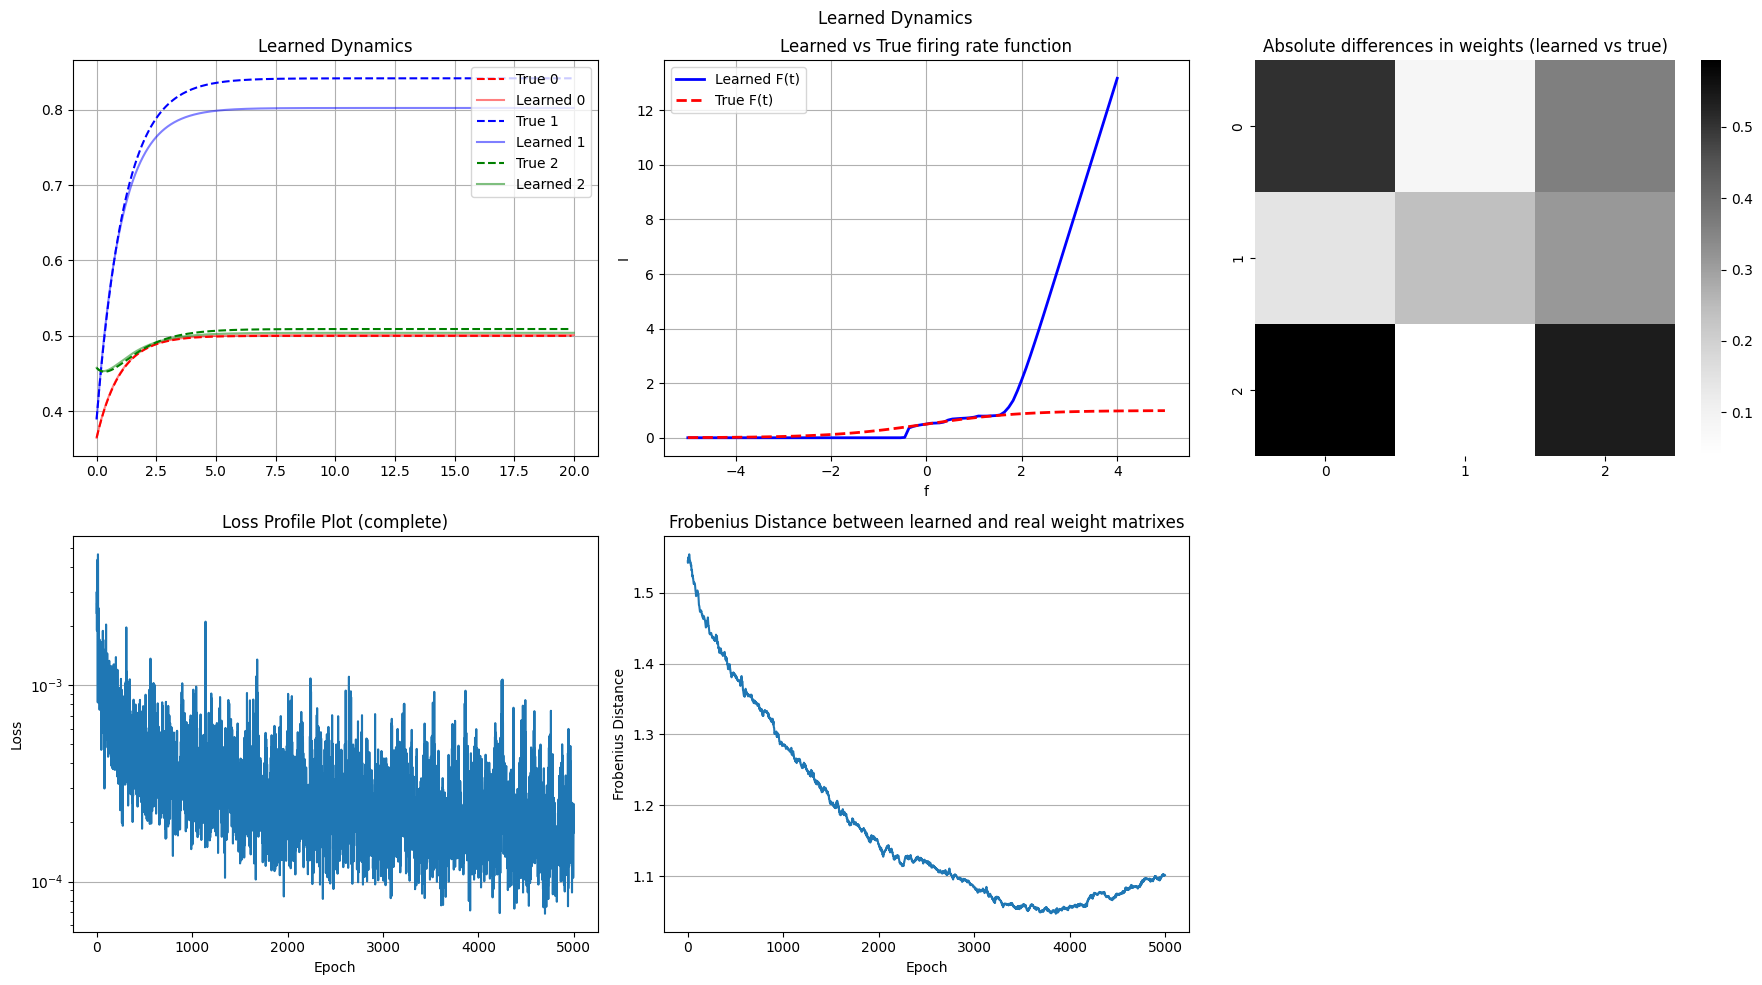

In [138]:
plt.figure(figsize=(18, 10))
plt.suptitle("Post-Training with Dropouts")

# Plot 1: dynamics

t_plot = torch.linspace(-5, 4, 100)
mixed_monkeys.eval()

with torch.no_grad():
    I_learned = torch.stack([mixed_monkeys.net(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()

T_MAX = 20

plt.subplot(2, 3, 1)
sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = saved_x0, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(saved_W, NP_firing_rate_fun, saved_I),
                atol = 1e-8, rtol=1e-8)

plt.suptitle("Learned Dynamics")

pred = odeint(mixed_monkeys, x0_torch, torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

colors = ['r', 'b', 'g', 'y', 'k']

for i in range(3):
    plt.plot(sol.t, sol.y[i, :], f"{colors[i]}--", label=f"True {i}")
    plt.plot(np.arange(0, T_MAX, 0.01), pred[:, i].cpu().detach().numpy(), f"{colors[i]}",label=f"Learned {i}", alpha=0.5)

plt.grid()

plt.title("Learned Dynamics")
plt.legend(loc="upper right")

# --- plot 2: firing rate


plt.subplot(2, 3, 2)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')
t_true = np.linspace(-5, 5, 100)
I_true = NP_firing_rate_fun(t_true)
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('f')
plt.ylabel('I')
plt.legend()
plt.title('Learned vs True firing rate function')
plt.grid()


# Plot 3: Plot difference between weight matrixes

plt.subplot(2,3, 3)

with torch.no_grad():
    sns.heatmap((np.abs(mixed_monkeys.W.detach().numpy()- saved_W)), cmap="Greys")
plt.title("Absolute differences in weights (learned vs true)")


# Plot 4: losses with semilogy

plt.subplot(2, 3, 4)
plt.semilogy(range(len(losses)), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.title("Loss Profile Plot (complete)")

# plot 5: 2-norm between matrixes

plt.subplot(2,3, 5)
plt.plot(range(len(frobenius_distances)), frobenius_distances)
plt.xlabel("Epoch")
plt.ylabel("Frobenius Distance")
plt.title("Frobenius Distance between learned and real weight matrixes")
plt.grid(axis="y")

plt.tight_layout()
plt.show()


In [139]:
torch.save(mixed_monkeys.state_dict(), "./models_weights/finetuned_with_dropout.dinomeng")

## 2.2. no

In [140]:

saved_W = np.loadtxt("./cool_parameters/W_case2.np")
saved_I = np.loadtxt("./cool_parameters/I_case2.np")
saved_x0 = np.loadtxt("./cool_parameters/x0_case2.np")

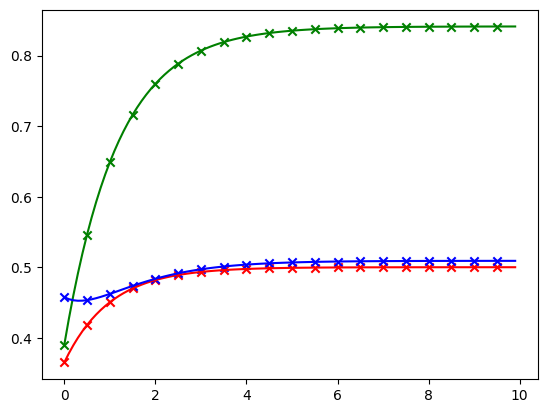

In [141]:
NEURON_NUM = 3
T_MAX = 10

sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = saved_x0, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(saved_W, NP_firing_rate_fun, saved_I),
                atol = 1e-8, rtol=1e-8)

                
data = sol.y[:, ::5]
t = sol.t[::5]

data_train = data
t_train = t

colors = ['r', 'g', 'b']

for i in range(NEURON_NUM):
    plt.plot(sol.t, sol.y[i], color=colors[i])
    plt.scatter(t_train, data_train[i, :], marker="x", color=colors[i])


In [142]:
def TORCH_firing_rate_fun(x):
    return 1 / (1 + torch.exp(-x))

class many_monkeys_mixed(nn.Module):
    def __init__(self, I0):
        super().__init__()


        self.register_buffer("I0", torch.tensor(I0, dtype=torch.float32))
        self.register_parameter("W", nn.Parameter(torch.zeros((NEURON_NUM, NEURON_NUM))))

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Softplus(),
        )

        # self.register_parameter("W", nn.Parameter(torch.tensor(saved_W, dtype=torch.float32))) # cheating mode

    def forward(self, t, data):
        x = self.I0 + self.W @ data.squeeze()
        x = x.unsqueeze(-1)
        out = self.net(x).squeeze(-1)
        return - data + out



In [143]:
# Train (fake) UDE network to training data
from tqdm import tqdm 
mixed_monkeys = many_monkeys_mixed(saved_I)

optimizer = optim.Adamax(mixed_monkeys.parameters(), lr=0.01)

x0_torch = torch.tensor(saved_x0, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
data_train_torch = torch.tensor(data_train, dtype=torch.float32).T
W_tensor = torch.tensor(saved_W, dtype=torch.float32)

train_losses = []
frobenius_distances = []

print("Epoch\tLoss (L2 norm)\t2-norm difference in weight matrixes")
for EPOCH in (range(1, 10000)):
    optimizer.zero_grad()
    mixed_monkeys.train()

    # get forward solution
    info = odeint(mixed_monkeys, x0_torch, T_train_torch,
                  rtol=1e-8, atol=1e-8, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - data_train_torch), 2)**2 
    loss_norm = loss_norm / T_train_torch.shape[0]

    loss_norm = loss_norm
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        mixed_monkeys.eval()

        x_pred_train = odeint(mixed_monkeys, x0_torch, T_train_torch,
                  rtol=1e-8, atol=1e-8, method='rk4')

        train_loss = (torch.norm((x_pred_train - data_train_torch), 2)**2 )/T_train_torch.shape[0]

        print(f"{EPOCH}\t{train_loss:.3E}\t{torch.norm(mixed_monkeys.W-W_tensor, 2):4f}")

        train_losses.append(train_loss.detach().numpy())
        frobenius_distances.append(torch.norm(mixed_monkeys.W-W_tensor, 2).detach().numpy())


Epoch	Loss (L2 norm)	2-norm difference in weight matrixes
1	6.300E-02	2.449673
2	3.647E-02	2.444062
3	1.982E-02	2.440107
4	1.251E-02	2.436105
5	4.411E-03	2.432697
6	3.930E-03	2.430437
7	1.098E-02	2.428587
8	1.171E-02	2.426653
9	9.624E-03	2.424484
10	8.495E-03	2.423131
11	2.966E-03	2.422926
12	6.337E-04	2.422801
13	8.430E-04	2.422668
14	2.439E-03	2.422516
15	4.015E-03	2.422230
16	4.521E-03	2.421794
17	3.822E-03	2.421176
18	2.507E-03	2.420440
19	1.370E-03	2.419629
20	1.073E-03	2.418774
21	1.555E-03	2.418011
22	1.643E-03	2.417443
23	1.132E-03	2.417086
24	7.697E-04	2.416828
25	7.807E-04	2.416625
26	1.042E-03	2.416408
27	1.256E-03	2.416212
28	1.238E-03	2.415974
29	9.427E-04	2.415725
30	5.600E-04	2.415425
31	3.731E-04	2.415093
32	3.059E-04	2.414917
33	3.315E-04	2.414731
34	4.714E-04	2.414482
35	4.748E-04	2.414326
36	4.245E-04	2.414188
37	3.847E-04	2.414042
38	4.041E-04	2.413934
39	4.647E-04	2.413783
40	5.540E-04	2.413632
41	5.658E-04	2.413426
42	4.451E-04	2.413138
43	3.031E-04	2.412794
44	2.

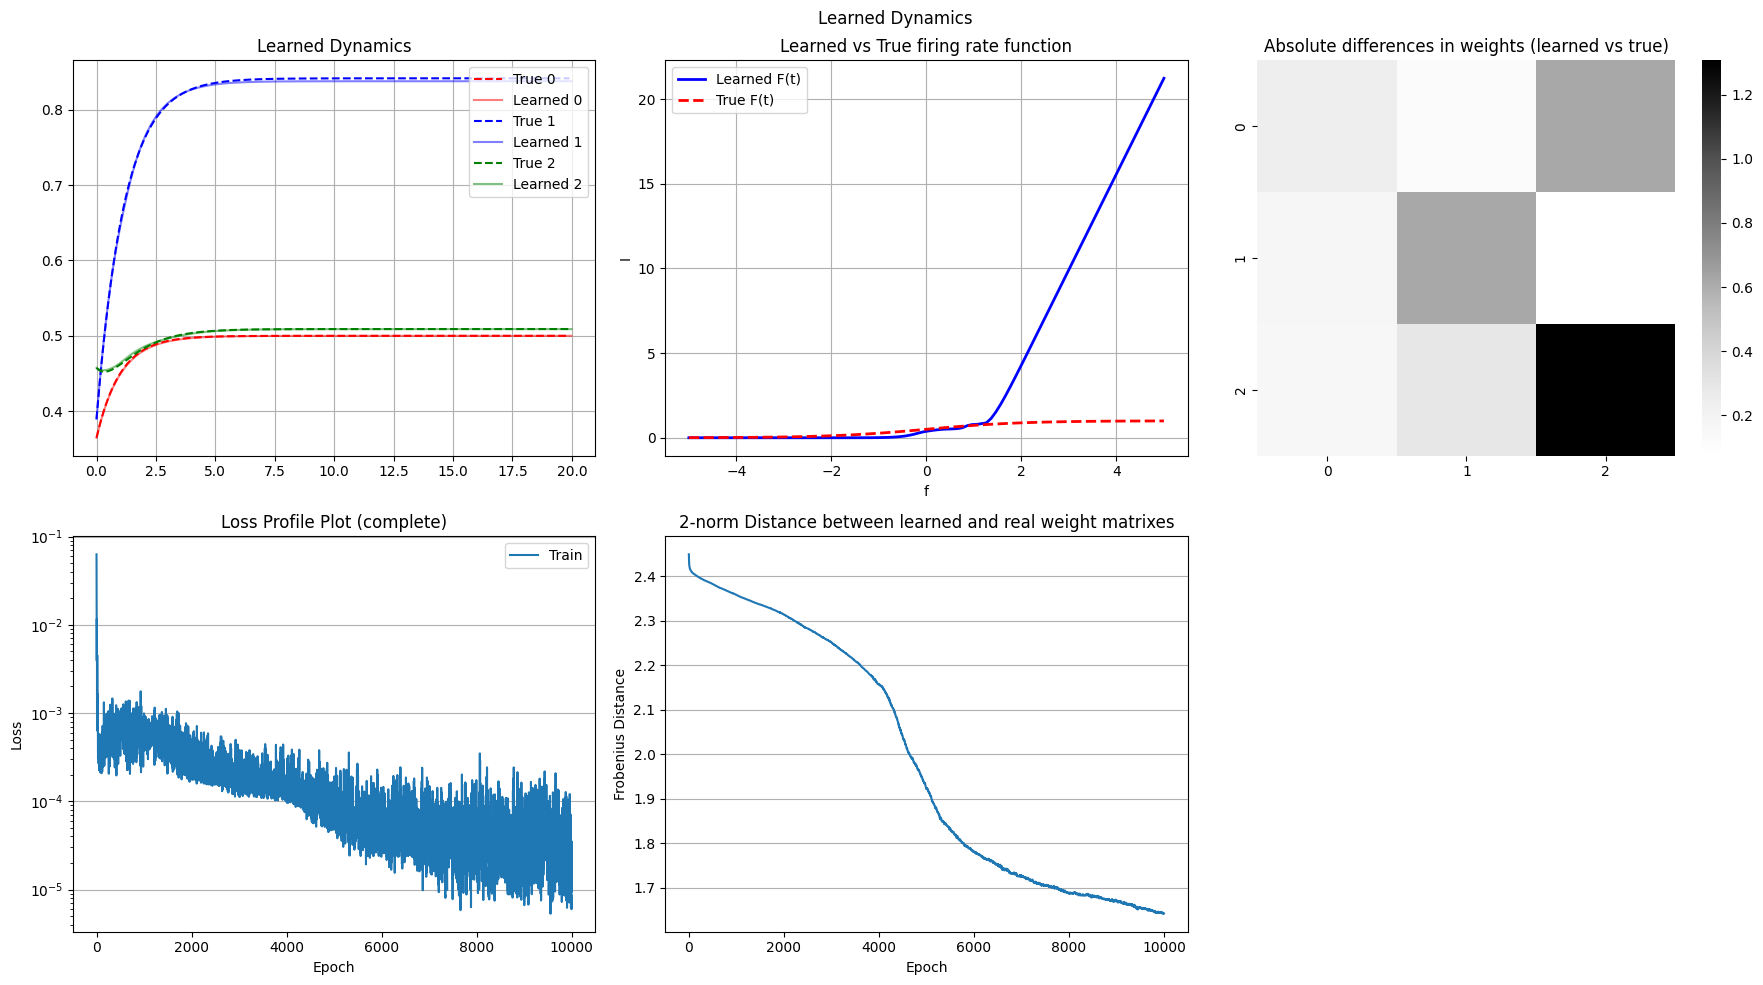

In [151]:
plt.figure(figsize=(18, 10))
plt.suptitle("Post-Training with Dropouts")

# Plot 1: dynamics

t_plot = torch.linspace(-5, 5, 100)
mixed_monkeys.eval()

with torch.no_grad():
    I_learned = torch.stack([mixed_monkeys.net(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()

T_MAX = 20

plt.subplot(2, 3, 1)
sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = saved_x0, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(saved_W, NP_firing_rate_fun, saved_I),
                atol = 1e-8, rtol=1e-8)

plt.suptitle("Learned Dynamics")

pred = odeint(mixed_monkeys, x0_torch, torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

colors = ['r', 'b', 'g', 'y', 'k']

for i in range(3):
    plt.plot(sol.t, sol.y[i, :], f"{colors[i]}--", label=f"True {i}")
    plt.plot(np.arange(0, T_MAX, 0.01), pred[:, i].cpu().detach().numpy(), f"{colors[i]}",label=f"Learned {i}", alpha=0.5)

plt.grid()

plt.title("Learned Dynamics")
plt.legend(loc="upper right")

# --- plot 2: firing rate


plt.subplot(2, 3, 2)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')
t_true = np.linspace(-5, 5, 100)
I_true = NP_firing_rate_fun(t_true)
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('f')
plt.ylabel('I')
plt.legend()
plt.title('Learned vs True firing rate function')
plt.grid()


# Plot 3: Plot difference between weight matrixes

plt.subplot(2,3, 3)

with torch.no_grad():
    sns.heatmap((np.abs(mixed_monkeys.W.detach().numpy()- saved_W)), cmap="Greys")
plt.title("Absolute differences in weights (learned vs true)")


# Plot 4: losses with semilogy

plt.subplot(2, 3, 4)
plt.semilogy(range(len(train_losses)), train_losses, label="Train")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.legend()
plt.title("Loss Profile Plot (complete)")

# plot 5: 2-norm between matrixes

plt.subplot(2,3, 5)
plt.plot(range(len(frobenius_distances)), frobenius_distances)
plt.xlabel("Epoch")
plt.ylabel("Frobenius Distance")
plt.title("2-norm Distance between learned and real weight matrixes")
plt.grid(axis="y")

plt.tight_layout()
plt.show()


Not any better in any way... the only thing it managed to do was a reduced frobenius distance in less iterations (10000 vs 20000)

In [145]:
torch.save(mixed_monkeys.state_dict(), "./models_weights/mixed_monkeys_dropout.dinomeng")

# Experiment 1
I will try to use hyperparameter optimization on the winner-take all model, for the case with two steady states. The following code will serve as a basis for the .py script

In [4]:
# Part 1: Simulate neuron networks

# Winner take all mechanism [1]

def NP_firing_rate_fun(x):
    return 1 / (1 + np.exp(-x))

def many_monkeys_simple(t, data, phi, I, J):
    # Assume I0, J are constants
    r1 = data[0]
    r2 = data[1]

    try: 
        I(0)
    except: 
        return np.array([
            -r1 + phi(I - J*r2),
            -r2 + phi(I - J*r1),
        ])
    else:
        return np.array([
            -r1 + phi(I(t) - J*r2),
            -r2 + phi(I(t) - J*r1),
        ])


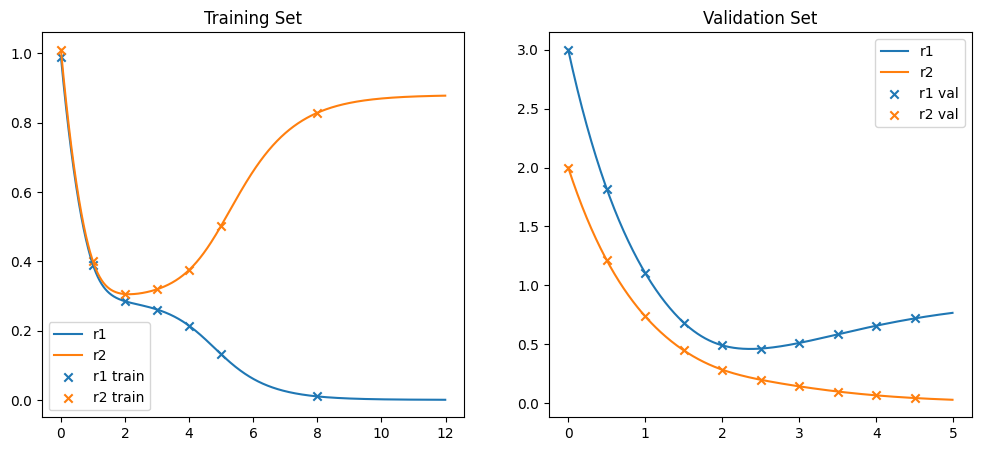

In [78]:
I0 = 2
J = 10
r_init = [0.99, 1.01]
T_MAX = 12

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol.y[0, :]
r2 = sol.y[1, :]

data_train = (sol.y[:, :551:100]).T
data_train = np.vstack((data_train, sol.y.T[-400, :]))

t_train = (sol.t[:551:100])
t_train = np.append(t_train, sol.t[-400])

fig, axes = plt.subplots(1, 2, figsize=(12,5))

plt.sca(axes[0])

plt.plot(sol.t, r1, label="r1")
plt.plot(sol.t, r2, label="r2")

plt.scatter(t_train, data_train[:, 0], label="r1 train", marker="x")
plt.scatter(t_train, data_train[:, 1], label="r2 train", marker="x")

plt.title("Training Set")
plt.legend()


plt.sca(axes[1])


r_init_val = [3, 2]
T_MAX_val = 5

sol_val = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX_val],
    y0 = np.array(r_init_val), 
    t_eval = np.arange(0, T_MAX_val, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol_val.y[0, :]
r2 = sol_val.y[1, :]

data_val = (sol_val.y[:, ::50]).T
t_val = (sol_val.t[::50])

plt.plot(sol_val.t, r1, label="r1")
plt.plot(sol_val.t, r2, label="r2")
plt.title("Validation Set")

plt.scatter(t_val, data_val[:, 0], label="r1 val", marker="x")
plt.scatter(t_val, data_val[:, 1], label="r2 val", marker="x")
plt.legend()
plt.show()

In [91]:
I0 = 2
J = 10
r_init = [0.99, 1.01]
T_MAX = 12

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol.y[0, :]
r2 = sol.y[1, :]

data_train = (sol.y[:, :551:100]).T
data_train = np.vstack((data_train, sol.y.T[-400, :]))

t_train = (sol.t[:551:100])
t_train = np.append(t_train, sol.t[-400])

r_init_val = [1, 1]
T_MAX_val = 5

sol_val = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX_val],
    y0 = np.array(r_init_val), 
    t_eval = np.arange(0, T_MAX_val, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol_val.y[0, :]
r2 = sol_val.y[1, :]

data_val = (sol_val.y[:, ::50]).T
t_val = (sol_val.t[::50])

In [92]:
r_init, r_init_val, t_train, t_val, data_train, data_val

([0.99, 1.01],
 [1, 1],
 array([0., 1., 2., 3., 4., 5., 8.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5]),
 array([[0.99      , 1.01      ],
        [0.39014208, 0.40013868],
        [0.28528188, 0.30596855],
        [0.26152526, 0.31983779],
        [0.21460535, 0.37559668],
        [0.1324426 , 0.50318553],
        [0.01104437, 0.82847669]]),
 array([[1.        , 1.        ],
        [0.60865308, 0.60865308],
        [0.39511476, 0.39511476],
        [0.31580284, 0.31580284],
        [0.2955237 , 0.2955237 ],
        [0.29096242, 0.29096242],
        [0.28996571, 0.28996571],
        [0.28974927, 0.28974927],
        [0.28970233, 0.28970233],
        [0.28969215, 0.28969215]]))

In [93]:
r_init_train_torch = torch.tensor(r_init, dtype=torch.float32)
r_init_val_torch = torch.tensor(r_init_val, dtype=torch.float32)
t_train_torch = torch.tensor(t_train, dtype=torch.float32)
t_val_torch = torch.tensor(t_val, dtype=torch.float32)
data_train_torch = torch.tensor(data_train, dtype=torch.float32)
data_val_torch = torch.tensor(data_val, dtype=torch.float32)


In [94]:
r_init_val_torch

tensor([1., 1.])

In [95]:
def TORCH_firing_rate_fun(x):
    return 1 / (1 + torch.exp(-x))

class learning_winnertakeall_monkeys(nn.Module):
    def __init__(self, I0, J):
        super().__init__()

        self.register_buffer("I0", torch.tensor([I0], dtype=torch.float32))
        self.register_buffer("J", torch.tensor([J], dtype=torch.float32))

        self.net = nn.Sequential(
            nn.Linear(1, 120),
            nn.SiLU(),
            nn.Linear(120, 128),
            nn.SiLU(),
            nn.Linear(128, 21),
            nn.SiLU(),
            nn.Linear(21, 1),
            nn.SiLU(),
        )

    def forward(self, t, data):
        activation_r1 = self.net(self.I0 - self.J*data[1]).squeeze()
        activation_r2 = self.net(self.I0 - self.J*data[0]).squeeze()
        out = -data + torch.stack((activation_r1, activation_r2), dim=-1)
        return out


In [96]:
# Train UDE network to training data
from tqdm import tqdm 
my_fighting_monkeys_exp2 = learning_winnertakeall_monkeys(I0, J)

lr = 1e-3
optimizer = torch.optim.Adam(my_fighting_monkeys_exp2.parameters(), lr)

x0_torch = torch.tensor(r_init, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
data_train_torch = torch.tensor(data_train, dtype=torch.float32)

for EPOCH in (range(1, 1000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_fighting_monkeys_exp2, x0_torch, T_train_torch, method='dopri5')

    # calculate loss
    loss_norm = torch.mean(torch.norm(info-data_train_torch, p=2, dim=1)**2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{loss_norm.item()}")
        pass

1	0.16129885613918304
2	0.1440982073545456
3	0.1311677247285843
4	0.12033218890428543
5	0.11134598404169083
6	0.10353140532970428
7	0.09649486094713211
8	0.09004931151866913
9	0.08412887156009674
10	0.07875073701143265
11	0.0740010216832161
12	0.07002869993448257
13	0.06701355427503586
14	0.06501467525959015
15	0.06365083158016205
16	0.061448194086551666
17	0.04750744253396988
18	0.10479464381933212
19	0.02879420481622219
20	0.05008099228143692
21	0.05700588971376419
22	0.060134243220090866
23	0.06185989826917648
24	0.06291147321462631
25	0.06355590373277664
26	0.06391147524118423
27	0.06404770165681839
28	0.06401779502630234
29	0.06386975198984146
30	0.06364645808935165
31	0.06338510662317276
32	0.06311387568712234
33	0.06285297125577927
34	0.06261444836854935
35	0.06240299344062805
36	0.06221815198659897
37	0.0620553195476532
38	0.06190735101699829
39	0.06176513805985451
40	0.06161849573254585
41	0.061456162482500076
42	0.06126509979367256
43	0.061030417680740356
44	0.060732923448085

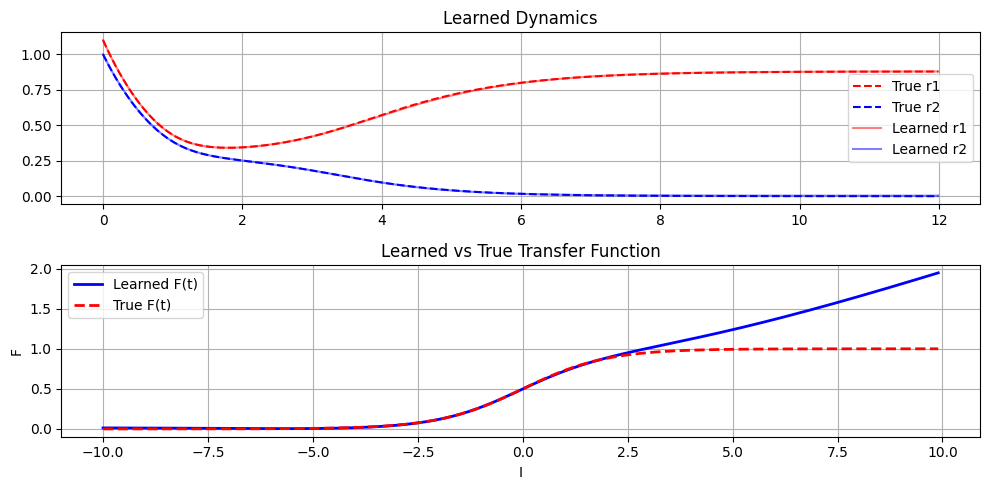

In [136]:
r_init = [1.1, 1]

pred = odeint(my_fighting_monkeys_exp2, torch.tensor(r_init, dtype=torch.float32), torch.arange(0, 12, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)


T_MAX = 12

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)
r1 = sol.y[0, :]
r2 = sol.y[1, :]

fig, axes = plt.subplots(2, 1, figsize=(10,5))

plt.sca(axes[0])
plt.plot(sol.t, r1, "r--", label="True r1")
plt.plot(sol.t, r2, "b--", label="True r2")

plt.plot(np.arange(0, 12, 0.01), pred[:, 0].cpu().detach().numpy(), label="Learned r1", color="r", alpha=0.5)
plt.plot(np.arange(0, 12, 0.01), pred[:, 1].cpu().detach().numpy(), label="Learned r2", color="b", alpha=0.5)

plt.grid()

plt.title("Learned Dynamics")
plt.legend()

i_plot = torch.arange(-10, 10, 0.1)
with torch.no_grad():
    act_learned = torch.stack([my_fighting_monkeys_exp2.net(torch.tensor([[I]], dtype=torch.float32)) 
                             for I in i_plot]).squeeze()

# Plot 1: Learned Activation vs true activation
plt.sca(axes[1
])
plt.plot(i_plot.numpy(), act_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')

i_true = np.arange(-10, 10, 0.1)

act_true = NP_firing_rate_fun(i_true)

plt.plot(i_true, act_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('I')
plt.ylabel('F')
plt.legend()
plt.title('Learned vs True Transfer Function')
plt.grid()

plt.tight_layout()
plt.show()

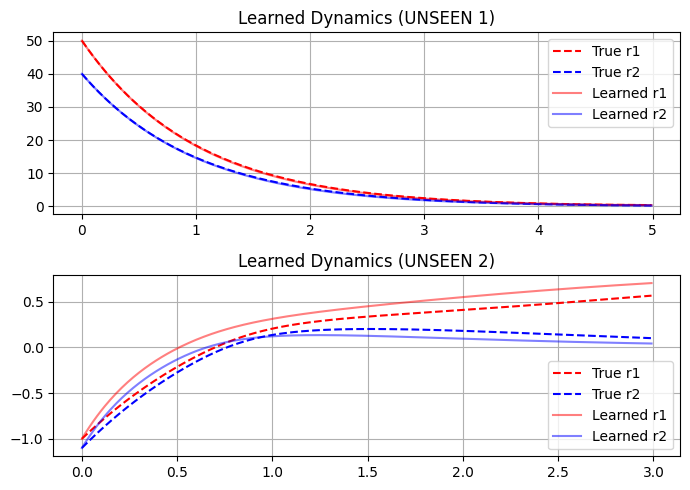

In [168]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5))
# plot 2: negative values (biologically impossible!!!)



plt.sca(axes[0])

r_init = [50, 40]


T_MAX = 5

pred_2 = odeint(my_fighting_monkeys_exp2, torch.tensor(r_init, dtype=torch.float32), torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)
r1 = sol.y[0, :]
r2 = sol.y[1, :]

plt.plot(sol.t, r1, "r--", label="True r1")
plt.plot(sol.t, r2, "b--", label="True r2")

plt.plot(np.arange(0, T_MAX, 0.01), pred_2[:, 0].cpu().detach().numpy(), label="Learned r1", color="r", alpha=0.5)
plt.plot(np.arange(0, T_MAX, 0.01), pred_2[:, 1].cpu().detach().numpy(), label="Learned r2", color="b", alpha=0.5)

plt.grid()

plt.title("Learned Dynamics (UNSEEN 1)")
plt.legend()

plt.sca(axes[1])

r_init = [-1, -1.1]


T_MAX = 3

pred_2 = odeint(my_fighting_monkeys_exp2, torch.tensor(r_init, dtype=torch.float32), torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)
r1 = sol.y[0, :]
r2 = sol.y[1, :]

plt.plot(sol.t, r1, "r--", label="True r1")
plt.plot(sol.t, r2, "b--", label="True r2")

plt.plot(np.arange(0, T_MAX, 0.01), pred_2[:, 0].cpu().detach().numpy(), label="Learned r1", color="r", alpha=0.5)
plt.plot(np.arange(0, T_MAX, 0.01), pred_2[:, 1].cpu().detach().numpy(), label="Learned r2", color="b", alpha=0.5)

plt.grid()

plt.title("Learned Dynamics (UNSEEN 2)")
plt.legend()

plt.tight_layout()
plt.show()



In [133]:
torch.save(my_fighting_monkeys_exp2.state_dict(), "./models_weights/wta-model-optimized-1.dinomeng")